Epoch 1, Loss: 1.5088738203048706
Epoch 2, Loss: 1.3874632120132446
Epoch 3, Loss: 1.3181841373443604
Epoch 4, Loss: 1.2689985036849976
Epoch 5, Loss: 1.2569530010223389
Epoch 6, Loss: 1.2524819374084473
Epoch 7, Loss: 1.258847951889038
Epoch 8, Loss: 1.2429089546203613
Epoch 9, Loss: 1.261395812034607
Epoch 10, Loss: 1.251205563545227
Epoch 11, Loss: 1.2595536708831787
Epoch 12, Loss: 1.2494314908981323
Epoch 13, Loss: 1.239048719406128
Epoch 14, Loss: 1.2269539833068848
Epoch 15, Loss: 1.2393375635147095
Epoch 16, Loss: 1.2372605800628662
Epoch 17, Loss: 1.2458441257476807
Epoch 18, Loss: 1.2334197759628296
Epoch 19, Loss: 1.2181591987609863
Epoch 20, Loss: 1.219102382659912
Epoch 21, Loss: 1.2109819650650024
Epoch 22, Loss: 1.211326003074646
Epoch 23, Loss: 1.2239861488342285
Epoch 24, Loss: 1.2096792459487915
Epoch 25, Loss: 1.211010456085205
Epoch 26, Loss: 1.2185149192810059
Epoch 27, Loss: 1.2069480419158936
Epoch 28, Loss: 1.1601359844207764
Epoch 29, Loss: 1.1865860223770142
E

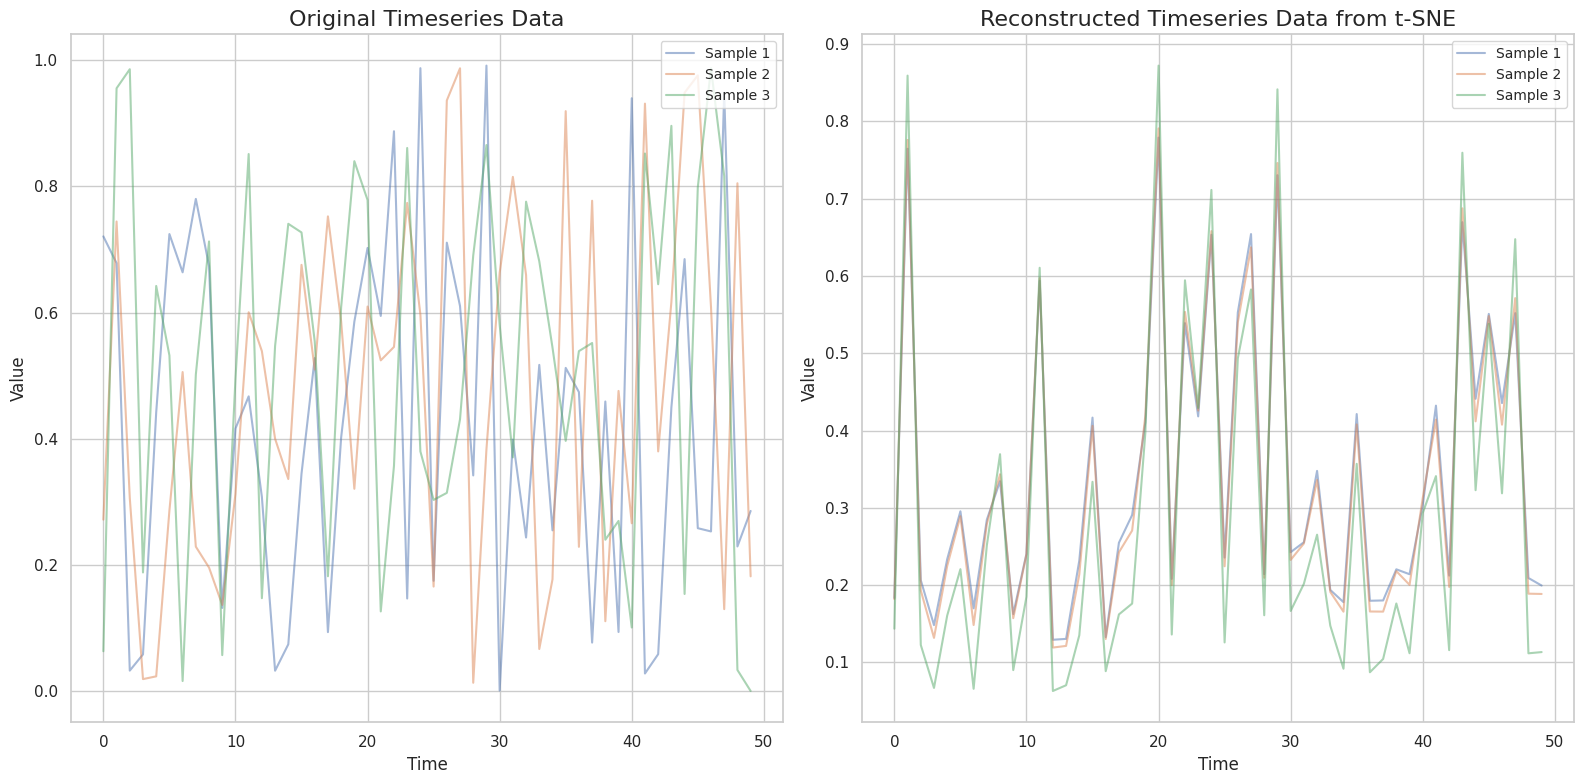

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.manifold import TSNE
from keras import layers, models

def generate_timeseries_data(num_samples, num_timesteps):
    """
    Generate synthetic timeseries data.

    Parameters:
        num_samples (int): Number of samples in the dataset.
        num_timesteps (int): Number of timesteps in each sample.

    Returns:
        np.ndarray: Generated timeseries data with shape (num_samples, num_timesteps).
    """
    return np.random.rand(num_samples, num_timesteps)

class VAE(models.Model):


    def __init__(self, input_dim, latent_dim):
        super(VAE, self).__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim

        self.encoder = self.build_encoder()
        self.decoder = self.build_decoder()

    def build_encoder(self):
        encoder_input = layers.Input(shape=(self.input_dim,))
        x = layers.Dense(128, activation='relu')(encoder_input)
        z_mean = layers.Dense(self.latent_dim)(x)
        z_log_var = layers.Dense(self.latent_dim)(x)
        encoder_output = layers.Lambda(self.sample_z, output_shape=(self.latent_dim,))([z_mean, z_log_var])
        return models.Model(encoder_input, [z_mean, z_log_var, encoder_output])  # Ensure to return all three outputs

    def build_decoder(self):
        decoder_input = layers.Input(shape=(self.latent_dim,))
        x = layers.Dense(128, activation='relu')(decoder_input)
        decoder_output = layers.Dense(self.input_dim, activation='sigmoid')(x)
        return models.Model(decoder_input, decoder_output)

    def sample_z(self, args):
        z_mean, z_log_var = args
        batch_size = tf.shape(z_mean)[0]
        latent_dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch_size, latent_dim), mean=0., stddev=1.0)
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)  # Correctly unpack all three outputs
        reconstructions = self.decoder(z)
        return reconstructions, z_mean, z_log_var


def vae_loss(y_true, y_pred, z_mean, z_log_var):

    mse_loss = tf.keras.losses.MeanSquaredError()
    recon_loss = mse_loss(y_true, y_pred)
    kl_loss = -0.5 * tf.reduce_mean(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
    return recon_loss + kl_loss

def main(num_samples, num_timesteps, latent_dim, epochs, batch_size):
    # Generate synthetic timeseries data
    data = generate_timeseries_data(num_samples, num_timesteps)

    # Normalize the data
    data_mean = data.mean()
    data_std = data.std()
    data_normalized = (data - data_mean) / data_std

    # Create VAE model
    vae = VAE(num_timesteps, latent_dim)
    vae.compile(optimizer='adam')  # Remove the custom loss from here

    # Custom training loop
    for epoch in range(epochs):
        with tf.GradientTape() as tape:
            reconstructions, z_mean, z_log_var = vae(data_normalized)
            loss = vae_loss(data_normalized, reconstructions, z_mean, z_log_var)  # Pass the outputs to the loss function

        grads = tape.gradient(loss, vae.trainable_variables)
        vae.optimizer.apply_gradients(zip(grads, vae.trainable_variables))

        print(f'Epoch {epoch + 1}, Loss: {loss.numpy()}')  # Print the loss for each epoch

    # Reduce dimensionality of timeseries using the trained encoder
    z_mean, z_log_var, encoded_data = vae.encoder.predict(data_normalized)  # Unpack the outputs to get the encoded data

    # Set the style of the plots
    sns.set(style="whitegrid")

    plt.figure(figsize=(16, 8))  # Increased the figure size

    # Plot the original timeseries data
    plt.subplot(1, 2, 1)
    plt.title("Original Timeseries Data", fontsize=16)
    for i in range(num_samples):
        plt.plot(data[i], alpha=0.5, label=f"Sample {i+1}")
    plt.xlabel("Time", fontsize=12)
    plt.ylabel("Value", fontsize=12)
    plt.legend(loc='upper right', fontsize=10)
    plt.grid(True)

    # Plot the reconstructed timeseries data after applying t-SNE
    decoded_data_tsne = vae.decoder.predict(encoded_data)
    plt.subplot(1, 2, 2)
    plt.title("Reconstructed Timeseries Data from t-SNE", fontsize=16)
    for i in range(num_samples):
        plt.plot(decoded_data_tsne[i], alpha=0.5, label=f"Sample {i+1}")
    plt.xlabel("Time", fontsize=12)
    plt.ylabel("Value", fontsize=12)
    plt.legend(loc='upper right', fontsize=10)
    plt.grid(True)

    plt.subplots_adjust(wspace=0.4)  # Added space between the subplots
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # Directly call main with desired parameters:
    num_samples = 3
    num_timesteps = 50
    latent_dim = 2
    epochs = 100
    batch_size = 32
    main(num_samples, num_timesteps, latent_dim, epochs, batch_size)
